# Evaluación 2 · Sección 1 — Los datos y su calidad

Este notebook consolida, en un solo archivo, la progresión completa de la Sección 1 de la pauta Los datos y su calidad: la exploración inicial de las cinco tablas, la profundización en las tres pruebas de puntaje que resultaron ser las variables centrales del proyecto, y el checklist formal de calidad exigido por la rúbrica de Evaluación 2, de acuerdo con lo establecido en el entregable Formulación del Proyecto Capstone

**Contenido:**
- Exploración inicial de datos 
- Exploración de `CLEC_MAX` 
- Exploración de `MATE1_MAX` 
- Exploración de `MATE2_MAX` 
- Checklist formal de calidad 

---
# Parte 1: Exploración inicial de datos

# Exploración de datos PAES 2026

En este apartado, realizaremos una primera revisión de los conjuntos de datos. El objetivo es conocer la estructura y contenido en terminos de datos de cada fuente, utilizando como referencia el archivo PDF que acompaña a cada fuente y que entrega, entre otros, información sobre: observaciones según proceso de admisión, responsable del dato en particular, variables (nombre, tipo, descripción y valores) asi como también códigos asociados a las unidades territoriales. 

Para esta experiencia se toma como referencia los contenidos de clases, evaluando en cada conjunto lo siguiente: 

- dimensiones del conjunto
- primeras observaciones
- variables y tipos de datos
- valores faltantes
- posibles duplicados
- variables cualitativas y cuantitativas relevantes
- posibles identificadores o llaves primarias
- unidad de observación de cada tabla

El proceso se realizará con cada archivo, aun cuando esto podria hacerse de forma paralela. La idea es, apoyados en el PDF de cada archivo, ir generando un dominio acabado de cada dataset.  

La forma de trabajo definida utiliza los archivos disponibles en `data/raw/2026` como referencia. Durante el proceso de análisis exploratorio y/o transformacion, los datasets quedaran en `data/intermediate`, en caso de que se requiera complementar o realizar algún paso adicional. Finalmente, el conjunto preparado y listo para análisis quedara en `data/processed`

In [3]:
from pathlib import Path
import pandas as pd

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"/ "2026"


## Inscritos y Puntajes

Comenzaremos con el conjunto `A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv`

In [4]:
#Definimos CARPETA / Archivo
RUTA_INSCRITOS = RAW_DIR / "PAES-2026-Inscritos-Puntajes" / "A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv" 

# Primero miramos el archivo RAW. Si bien podriamos haber definido un comando para leer ya formateado el archivo, la idea es 
# poder entender en operación que esperar para definir un metodo de lectura. 
with open(RUTA_INSCRITOS, "r", encoding="utf-8") as archivo:
    for _ in range(3):
        print(archivo.readline())


MRUN;ANYO_PROCESO;COD_SEXO;FECHA_NACIMIENTO;RBD;CODIGO_ENS;LOCAL_EDUCACIONAL;UNIDAD_EDUCATIVA;NOMBRE_UNIDAD_EDUC;RAMA_EDUCACIONAL;DEPENDENCIA;CODIGO_REGION_EGRESO;NOMBRE_REGION_EGRESO;CODIGO_PROVINCIA_EGRESO;NOMBRE_PROVINCIA_EGRESO;CODIGO_COMUNA_EGRESO;NOMBRE_COMUNA_EGRESO;ANYO_DE_EGRESO;PROMEDIO_NOTAS;PTJE_NEM;PORC_SUP_NOTAS;PTJE_RANKING;CLEC_REG_ACTUAL;MATE1_REG_ACTUAL;MATE2_REG_ACTUAL;HCSOC_REG_ACTUAL;CIEN_REG_ACTUAL;CLEC_INV_ACTUAL;MATE1_INV_ACTUAL;MATE2_INV_ACTUAL;HCSOC_INV_ACTUAL;CIEN_INV_ACTUAL;CLEC_REG_ANTERIOR;MATE1_REG_ANTERIOR;MATE2_REG_ANTERIOR;HCSOC_REG_ANTERIOR;CIEN_REG_ANTERIOR;CLEC_INV_ANTERIOR;MATE1_INV_ANTERIOR;MATE2_INV_ANTERIOR;HCSOC_INV_ANTERIOR;CIEN_INV_ANTERIOR;PROMEDIO_CM_MAX;CLEC_MAX;MATE1_MAX;MATE2_MAX;HCSOC_MAX;CIEN_MAX;RINDIO_PROCESO_ANTERIOR;RINDIO_PROCESO_ACTUAL;HABILITACION_POST;PRUEBA_REG_CL;FORMA_REG_CL;CORRECTAS_REG_CL;ERRADAS_REG_CL;OMITIDAS_REG_CL;PRUEBA_REG_M1;FORMA_REG_M1;CORRECTAS_REG_M1;ERRADAS_REG_M1;OMITIDAS_REG_M1;PRUEBA_REG_M2;FORMA_REG_M2;CO

El resultado del codigo nos muestra que el separador utilizado en el .csv es `;` según el registro `MRUN;ANYO_PROCESO;COD_SEXO;FECHA_NACIMIENTO;RBD;`. En general uno podria asumir que para estos archivos .csv, preparados por un mismo ente, siempre el separador será `;`, pero es una buena practica revisar el texto raw antes de declararlo en lectura como el ejemplo de clases: `viajes = pd.read_csv("viajes.csv", sep=";", decimal=",", low_memory=False)`


In [5]:
inscritos = pd.read_csv (RUTA_INSCRITOS, sep = ";", decimal= ",", low_memory=False)
inscritos

,MRUN,ANYO_PROCESO,COD_SEXO,FECHA_NACIMIENTO,RBD,CODIGO_ENS,LOCAL_EDUCACIONAL,UNIDAD_EDUCATIVA,NOMBRE_UNIDAD_EDUC,RAMA_EDUCACIONAL,...,PRUEBA_INV_CQUI,FORMA_INV_CQUI,CORRECTAS_INV_CQUI,ERRADAS_INV_CQUI,OMITIDAS_INV_CQUI,PRUEBA_INV_CTP,FORMA_INV_CTP,CORRECTAS_INV_CTP,ERRADAS_INV_CTP,OMITIDAS_INV_CTP
0,89,2026,2,200708,2308,310,1326,1,COLEGIO SAN ANTONIO DEL BALUARTE,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
1,258,2026,1,200704,12305,310,2157,1,COLEGIO ALEXANDER FLEMING,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
2,259,2026,2,200704,8005,510,2701,7,LICEO AYTUE,T2,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
3,496,2026,2,200711,10967,510,60,3,LICEO ELEUTERIO RAMIREZ MOLINA,T2,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
4,538,2026,2,200711,26538,310,4041,1,COLEGIO TERRAUSTRAL OESTE S.A,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320082,28540477,2026,1,200712,4708,410,1658,5,LICEO POLIVALENTE LAS SALINAS,T1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
320083,28540478,2026,2,200705,218,610,61,4,LICEO FRANCISCO DE AGUIRRE,T3,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
320084,28540479,2026,2,200805,9900,610,836,5,COLEGIO BICENTENARIO DE EXCELENCIA POLITECNICO...,T3,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
320085,28540480,2026,1,200802,3110,310,6906,1,COMPLEJO EDUCACIONAL MAULE,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0


Con la tabla anterior de resultado, ya tenemos un dataframe conceptualmente reconocible, por lo que procedemos a realizar las exploraciones basicas revisadas en clases. 

In [6]:
inscritos.shape # Para conocer filas, columnas

(320087, 131)

In [7]:
inscritos.head() # Para conocer las primeras filas, aunque esto de alguna forma ya lo obtuvimos al mostrar inscritos

,MRUN,ANYO_PROCESO,COD_SEXO,FECHA_NACIMIENTO,RBD,CODIGO_ENS,LOCAL_EDUCACIONAL,UNIDAD_EDUCATIVA,NOMBRE_UNIDAD_EDUC,RAMA_EDUCACIONAL,...,PRUEBA_INV_CQUI,FORMA_INV_CQUI,CORRECTAS_INV_CQUI,ERRADAS_INV_CQUI,OMITIDAS_INV_CQUI,PRUEBA_INV_CTP,FORMA_INV_CTP,CORRECTAS_INV_CTP,ERRADAS_INV_CTP,OMITIDAS_INV_CTP
0,89,2026,2,200708,2308,310,1326,1,COLEGIO SAN ANTONIO DEL BALUARTE,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
1,258,2026,1,200704,12305,310,2157,1,COLEGIO ALEXANDER FLEMING,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
2,259,2026,2,200704,8005,510,2701,7,LICEO AYTUE,T2,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
3,496,2026,2,200711,10967,510,60,3,LICEO ELEUTERIO RAMIREZ MOLINA,T2,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0
4,538,2026,2,200711,26538,310,4041,1,COLEGIO TERRAUSTRAL OESTE S.A,H1,...,Ciencias Química.,0,0,0,0,Ciencias Técnico Profesional.,0,0,0,0


Para conocer el detalle de las columnas utilizamos .info(). Dado que el archivo contiene 131 columnas es bastante probable que la funcion retorne un cuadro de resumen basico.

Por lo anterior, y como nosotros esperamos obtener información mas precisa, utilizamos la funcion con el argumento: 
verbose=True para forzar mostrar el detalle completo y
show_counts=True para mostrar el conteo de valores no nulos.

In [8]:
inscritos.info(verbose=True,show_counts=True) 

<class 'pandas.DataFrame'>
RangeIndex: 320087 entries, 0 to 320086
Data columns (total 131 columns):
 #    Column                   Non-Null Count   Dtype  
---   ------                   --------------   -----  
 0    MRUN                     320087 non-null  int64  
 1    ANYO_PROCESO             320087 non-null  int64  
 2    COD_SEXO                 320087 non-null  int64  
 3    FECHA_NACIMIENTO         320087 non-null  int64  
 4    RBD                      320087 non-null  str    
 5    CODIGO_ENS               320087 non-null  str    
 6    LOCAL_EDUCACIONAL        320087 non-null  str    
 7    UNIDAD_EDUCATIVA         320087 non-null  str    
 8    NOMBRE_UNIDAD_EDUC       316887 non-null  str    
 9    RAMA_EDUCACIONAL         319624 non-null  str    
 10   DEPENDENCIA              320087 non-null  str    
 11   CODIGO_REGION_EGRESO     320087 non-null  str    
 12   NOMBRE_REGION_EGRESO     318876 non-null  str    
 13   CODIGO_PROVINCIA_EGRESO  320087 non-null  str    
 14

 En este dataset en particular vemos que algunas columnas como `NOMBRE_COMUNA_EGRESO`, muestran menos valores no nulos respecto de las observaciones totales, lo cual será revisado en consideracion a su relevancia para el estudio, mas adelante.

Un detalle particular en esta primera mirada es la definición del tipo de dato de `FECHA_NACIMIENTO`. En el archivo PDF se declara como una cadena o string (str) con formato AAAAMM pero en la info entregada por pandas, se declara como int64 (entero de 64 bits con signo), es decir, un numero. Si bien esto no necesariamente es un error de codificación o lectura, este tipo de detalles son relevantes a la hora de utilizar la información. Por lo que, una vez definido el conjunto de variables que efectivamente se utilizará, se deberán realizar las transformaciones necesarias para tratar de forma correcta la información contenida en cada variable. 

# Revisiones BASE

En un df con 131 columnas, hacer una revision estadistica de cada una parece demasiado, considerando aun la gran cantidad de trabajo que hace el codigo. 
Por lo tanto, partiremos con algunos checks que tienen sentido e iremos definiendo a medida que el trabajo avance la pertinencia de columnas a analizar.

La primera duda surge con el identificador MRUN que deberia ser unico por estudiante y considerando los 320087 registros, deberiamos tener esa cantidad de estudiantes. 

In [9]:
# Utilizando entonces la funcion .nunique() validaremos si esta hipotesis es correcta. 
inscritos["MRUN"].nunique() # Usamos ["MRUN"] para definir la columna en particular.
# El resultado es consistente. 


320087

Otro de los valores iniciales del DF es ANYO_PROCESO. Se podría asumir, dado que los datos corresponden al Proceso de Admisión 2026, que en esta fila deberían ser todos 2026. Lo corroboramos con value_counts() que nos entregara la cantidad de registros donde ANYO_PROCESO es 2026. Si hubiera un 2025 o cualquier otro valor, nos mostrara tambien ese resumen.

In [10]:
inscritos["ANYO_PROCESO"].value_counts()
# El resultado es consistente, ANYO_PROCESO solo considera 2026

ANYO_PROCESO
2026    320087
Name: count, dtype: int64

## Revisión de variables asociadas a la formulación del proyecto

Considerando la pregunta planteada en el proceso de formulacion del proyecto capstone, se identifican un conjunto inicial de variables para el EDA. 
Para ello, definiremos una lista de variables del proyecto a modo de acotar el dataset inicial y comenzar a trabajar en las variables a analizar. 

In [11]:
variables_trabajo = [
    "MRUN", 
    "CLEC_REG_ACTUAL", 
    "MATE1_REG_ACTUAL", 
    "MATE2_REG_ACTUAL",
    "DEPENDENCIA",
    "RAMA_EDUCACIONAL", 
    "CODIGO_REGION_EGRESO",
    "NOMBRE_REGION_EGRESO"
]
inscritos[variables_trabajo].info()
# En esta funcion, tomamos inscritos que fue nuestra "varibale" asociada al dataframe que lee desde el .csv y seleccionamos
# el conjunto de variables/columnas que definimos en variables_trabajo y sobre esto aplicamos info()

# En esta oportunidad se ha dejado fuera columnas que no agregan valor dada la formulacion del proyecto, en esta etapa
# de todas formas, lo que hacemos es seleccionar las que se utilizamos para trabajar, nunca eliminar, por lo que de ser 
# necesario otros datos en el futuro, se pueden agregar sin problemas. 

<class 'pandas.DataFrame'>
RangeIndex: 320087 entries, 0 to 320086
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   MRUN                  320087 non-null  int64
 1   CLEC_REG_ACTUAL       320087 non-null  str  
 2   MATE1_REG_ACTUAL      320087 non-null  str  
 3   MATE2_REG_ACTUAL      320087 non-null  str  
 4   DEPENDENCIA           320087 non-null  str  
 5   RAMA_EDUCACIONAL      319624 non-null  str  
 6   CODIGO_REGION_EGRESO  320087 non-null  str  
 7   NOMBRE_REGION_EGRESO  318876 non-null  str  
dtypes: int64(1), str(7)
memory usage: 19.5 MB


Como resultado, obtenemos el resumen que nos entrega pandas de las variables seleccionadas, logrando el total de los registros en la mayoria de variables, excepto en 2. RAMA_EDUCACIONAL y NOMBRE_REGION_EGRESO

Un detalle relevante es que las variables asociadas a puntajes se leen como str en vez de numerica, tal como indica documentación.

In [12]:
# Para un análisis mas en profundidad, utilizaremos una tabla para determinar tipos de variables, la cantidad de nulos 
# con su porcentaje y los valores unicos de las distintas columnas. 
# Para la Columna MRUN, deberiamos tener que todas las filas son unicos, tal como lo revisamos anteriormente, pero 
# en el caso de DEPENDENCIA, RAMA_EDUCACIONAL o CODIGO_REGION_EGRESO, deberemos ver un conjunto de valores que se repiten
# ya que estas columnas traen informacion de agrupacion. 

resumen_variables_trabajo = pd.DataFrame({
    "Tipo": inscritos[variables_trabajo].dtypes, 
    "Nulos": inscritos[variables_trabajo].isna().sum(),
    "% Nulos": inscritos[variables_trabajo].isna().mean()*100,
    "Valores Unicos": inscritos[variables_trabajo].nunique()
})

resumen_variables_trabajo # Lo muestra como tabla, mejor formato. 
# or 
#print(resumen_variables_trabajo)

,Tipo,Nulos,% Nulos,Valores Unicos
MRUN,int64,0,0.000000,320087
CLEC_REG_ACTUAL,str,0,0.000000,63
MATE1_REG_ACTUAL,str,0,0.000000,63
MATE2_REG_ACTUAL,str,0,0.000000,52
DEPENDENCIA,str,0,0.000000,7
RAMA_EDUCACIONAL,str,463,0.144648,9
CODIGO_REGION_EGRESO,str,0,0.000000,17
NOMBRE_REGION_EGRESO,str,1211,0.378335,16


La revisión anterior nos confirma la idea que antes ya habiamos respondido, `MRUN` es unica y se puede asociar a un alumno en particular. 
DEPENDENCIA mantiene misma condicion de no nulo, ya que hace referencia a que tipo de Establecimiento Educacional asistio el alumno. El sistema de admision requiere una institucion para poder rendir prueba. 
Para `RAMA_EDUCACIONAL` ya aparecen valores nulos, lo cual parece contraintuitivo, se supone que los establecimientos educacionales deben tener una orientacion especifica, mas adelante revisaremos el detalle y validaremos en base a documento e investigación como es que es posible tener NAs.
En CODIGO_REGION_EGRESO nuevamente tenemos 0 no nulos pero extrañamente NOMBRE_REGION_EGRESO si tiene valores nulos, los cuales tendremos que analizar en contexto para revisar si es un error que trae el dataset o un error al traer la informacion. 

Dado que hemos detectado situaciones de discrepancia entre lo esperado y lo obtenido, separaremos las variables en cuantitativas, puntajes particularmente y cualitativas, que tienen relacion con los atributos en terminos de categoria de las distintas variables. 

In [13]:
# Partiremos con las numericas, obteniendo Media (promedio), Mediana y Moda para los puntajes
# evaluando ademas la existencia de valores atipicos. 
# Pero como hemos identificado que el tipo de dato en celda se lee como string, deberemos hacer algun ajuste. 
# Entonces, primero listamos la columna para ver que datos contiene. 
inscritos["CLEC_REG_ACTUAL"].head(20)

0     597
1       0
2     467
3     455
4     841
5     576
6     607
7     467
8     455
9     525
10    782
11    860
12    860
13    650
14    555
15    397
16    690
17    500
18    607
19    756
Name: CLEC_REG_ACTUAL, dtype: str

En la ejecución vemos que efectivamente existen numeros en la columna y que pareciera existir una inconsistencia entre lo que se declara en PDF de apoyo vs lo que pandas interpreta. Puede incluso deberse al tipo de "formato" en el que se guardó el dato. 
Por lo tanto, con la ayuda de un par de funciones, revisaremos que mas hay dentro de esta columna, que sabemos por los análisis anteriores, no tiene valores no nulos, es decir, todas las filas tienen algo. 

In [14]:
CLEC_REG_ACTUAL_2_NUM = pd.to_numeric (
    inscritos["CLEC_REG_ACTUAL"],
    errors="coerce"
)
CLEC_REG_ACTUAL_2_NUM
# Revisamos si ahora podemos obtener la media, mediana, moda y definir algun criterio para valores atipicos.
print("Media: ", CLEC_REG_ACTUAL_2_NUM.mean().round(0))
print("Mediana: ", CLEC_REG_ACTUAL_2_NUM.median().round(0))
print("Moda: ", CLEC_REG_ACTUAL_2_NUM.mode().round(0))

Media:  509.0
Mediana:  576.0
Moda:  0    0.0
Name: CLEC_REG_ACTUAL, dtype: float64


Como Moda = 0, hacemos un contador de ceros sobre la columna para evaluar pertinencia

In [15]:
(CLEC_REG_ACTUAL_2_NUM == 0).sum()

np.int64(49518)

Este dato es bastante interesante ya que nos muestra que esta prueba podria no necesariamente ser un requisito, es decir, podria ser rendida o no. Lo que para el proposito de nuestra pregunta vale la pena considerar ya que quizas deberiamos mirar una variable final en vez de una situacional. 

Dado que estamos trabajando con puntajes, el obtener los percentiles sirve bastante para tener una idea general. 

In [16]:
CLEC_REG_ACTUAL_2_NUM.describe().round(0)

count    300591.0
mean        509.0
std         253.0
min           0.0
25%         455.0
50%         576.0
75%         682.0
max        1000.0
Name: CLEC_REG_ACTUAL, dtype: float64

Aca hace ruido que el count muestra un numero distinto de observaciones para la columna. Antes del cambio de str a numeric, teniamos 320087 observaciones, ahora este count nos muestra menos. Seria correcto asumir que son valores NaN? lo revisamos. 

In [17]:
print( "Valores NaN en Prueba Lectura: ", CLEC_REG_ACTUAL_2_NUM.isna().sum() )

Valores NaN en Prueba Lectura:  19496


Esto complejiza un poco mas el analisis final de la tabla. Cual es la diferencia de criterio entre NaN o 0? Será que existio una mala codificación? el dato efectivamente no esta o responde otra cosa? En que caso se coloca un 0 o un null? 

In [18]:
# Como no vamos ir a mirar el dataset completo, buscamos para la nueva variable
# identificar valores unicos en los NaN, que podrían ser un caracter especial, un Null u otro. 

inscritos.loc[
    CLEC_REG_ACTUAL_2_NUM.isna(),
    "CLEC_REG_ACTUAL"].unique()
# En este caso obtenemos un ' ', lo que indica que no existia dato, esta NULL - Vacio.

<StringArray>
[' ']
Length: 1, dtype: str

Al revisar la tabla de puntajes PAES publicada en el DEMRE `(https://demre.cl/paes/factores-seleccion/tabla-transformacion-puntajes-paes-regular-p2026-competencia-lectora)` podemos establecer que el rango de puntajes de las distintas pruebas esta en la escala de los 100 a 1000 puntos, valores bajo 100 o superiores a 1000 son considerados por definicion de la medicion como imposibles. 

Revisamos la columna considerando esta información.

In [19]:
valores_fuera_de_rango = CLEC_REG_ACTUAL_2_NUM [
    (CLEC_REG_ACTUAL_2_NUM < 100) | 
    (CLEC_REG_ACTUAL_2_NUM >1000)
]

cantidad_fuera_de_rango = valores_fuera_de_rango.shape[0]
porcentaje_fuera_de_rango = (
    cantidad_fuera_de_rango / CLEC_REG_ACTUAL_2_NUM.notna().sum()
) * 100

print(f"Registros fuera del rango [100, 1000]: {cantidad_fuera_de_rango:,}")
print(f"Porcentaje sobre los puntajes informados: {porcentaje_fuera_de_rango:.2f}%")
print("\nValores detectados:")
print(valores_fuera_de_rango.value_counts().sort_index())


Registros fuera del rango [100, 1000]: 49,518
Porcentaje sobre los puntajes informados: 16.47%

Valores detectados:
CLEC_REG_ACTUAL
0.0    49518
Name: count, dtype: int64


Finalmente utilizaremos un histograma para ver la distribucion de los puntajes en bandas de ancho 99 por ejemplo. Podria existir bandas de otro ancho una vez que se tenga mayor conocimiento del comportamiento de esta prueba en particular. 

In [20]:
# Primero definimos puntajes validos, es decir, solo los valores > 100 y menores o iguales a 1000. 
Puntajes_CLEC_validos = CLEC_REG_ACTUAL_2_NUM [
    CLEC_REG_ACTUAL_2_NUM.between(100,1000)
]

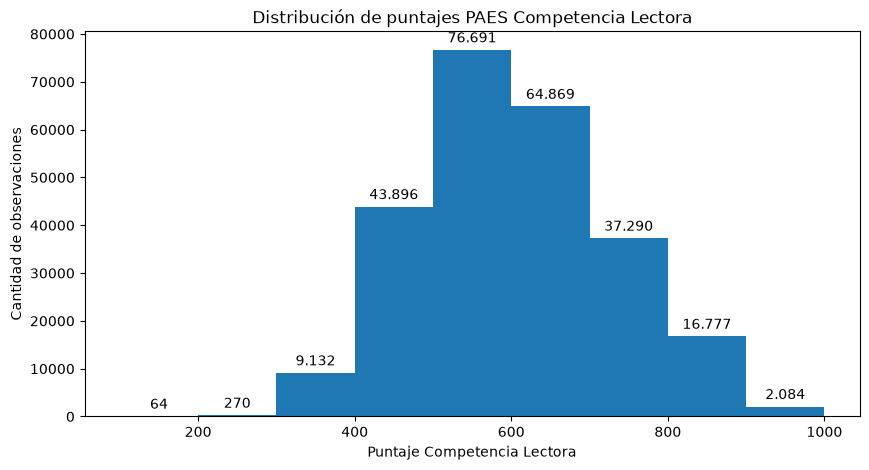

In [21]:
# Con ello, creamos un histograma para visualizar esto. 
import matplotlib.pyplot as plt

Puntajes_CLEC_validos = CLEC_REG_ACTUAL_2_NUM[
    CLEC_REG_ACTUAL_2_NUM.between(100, 1000)
]

plt.figure(figsize=(10, 5))

conteos, bordes, barras = plt.hist(
    Puntajes_CLEC_validos,
    bins=range(100, 1100, 100)
)

plt.xlabel("Puntaje Competencia Lectora")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Competencia Lectora")

plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],
    padding=3
)

plt.show()

In [22]:
tabla_bandas = pd.DataFrame({
    "Banda de puntaje": [
        f"{int(bordes[i])} - {int(bordes[i+1] - 1)}"
        for i in range(len(conteos))
    ],
    "Observaciones": conteos.astype(int)
})

# Corregimos la última banda para incluir el puntaje máximo 1000
tabla_bandas.loc[
    tabla_bandas.index[-1],
    "Banda de puntaje"
] = "900 - 1000"

tabla_bandas

,Banda de puntaje,Observaciones
0,100 - 199,64
1,200 - 299,270
2,300 - 399,9132
3,400 - 499,43896
4,500 - 599,76691
5,600 - 699,64869
6,700 - 799,37290
7,800 - 899,16777
8,900 - 1000,2084


In [23]:
tabla_bandas["Porcentaje"] = (
    tabla_bandas["Observaciones"]
    / tabla_bandas["Observaciones"].sum()
    * 100
).round(2)

tabla_bandas

,Banda de puntaje,Observaciones,Porcentaje
0,100 - 199,64,0.03
1,200 - 299,270,0.11
2,300 - 399,9132,3.64
3,400 - 499,43896,17.48
4,500 - 599,76691,30.55
5,600 - 699,64869,25.84
6,700 - 799,37290,14.85
7,800 - 899,16777,6.68
8,900 - 1000,2084,0.83


In [24]:
Puntajes_CLEC_validos.describe().round(0)

count    251073.0
mean        609.0
std         125.0
min         100.0
25%         511.0
50%         597.0
75%         690.0
max        1000.0
Name: CLEC_REG_ACTUAL, dtype: float64

## Resumen 
El analisis cuantitativo sobre los puntajes de competencia lectora nos permite definir la hoja de ruta para las otras dos variables. 
Tambien nos permite ya adelantar, que las variables definidas, que en un inicio tenian todo el sentido de ser las definitivas, se deben complementar o cambiar ya que las observaciones 0 o nulas no aportan a responder la pregunta. 

Para las variables cualitativas hacemos un `value_counts` para conocer las categorías de `RAMA_EDUCACIONAL`, `DEPENDENCIA` y `NOMBRE_REGION_EGRESO`. Los faltantes que aparezcan acá se retoman y resuelven en la sección 1.5.

In [25]:
inscritos["RAMA_EDUCACIONAL"].value_counts(dropna=False)

RAMA_EDUCACIONAL
H1     216909
T2      30721
T1      24819
T3      22147
H2      17760
T4       3820
H3       1993
H4        744
T5        711
NaN       463
Name: count, dtype: int64

Presencia de 463 NaN

In [26]:
inscritos["DEPENDENCIA"].value_counts(dropna=False)

DEPENDENCIA
3    168231
2     48543
4     35248
6     34372
1     19922
5     10571
       3200
Name: count, dtype: int64

Presencia de 3200 sin clasificación

In [27]:
inscritos["NOMBRE_REGION_EGRESO"].value_counts(dropna=False)

NOMBRE_REGION_EGRESO
REGION METROPOLITANA DE SANTIAGO                    123170
REGION DE VALPARAISO                                 32264
REGION DEL BIOBIO                                    29035
REGION DEL MAULE                                     20046
REGION DE LA ARAUCANIA                               18910
REGION DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS     17606
REGION DE COQUIMBO                                   15053
REGION DE LOS LAGOS                                  14503
REGION DE ANTOFAGASTA                                11002
REGION DE ÑUBLE                                       9028
REGION DE LOS RIOS                                    7067
REGION DE TARAPACA                                    6658
REGION DE ATACAMA                                     5213
REGION DE ARICA Y PARINACOTA                          4629
REGION DE MAGALLANES Y DE LA ANTARTICA CHILENA        2639
REGIÓN DE AYSEN                                       2053
NaN                                

Los NaN de `NOMBRE_REGION_EGRESO` y `CODIGO_REGION_EGRESO` son la misma cantidad. Se retoma en la sección 1.5.

---
# Parte 2: Exploración de Puntajes_MAX


# Exploración de CLEC_MAX

El análisis de `CLEC_REG_ACTUAL` cerró con una nota pendiente: evaluar si `CLEC_MAX` — y en conjunto con `MATE1_MAX` y `MATE2_MAX` — podrían ser las variables definitivas para el análisis final del proyecto, dado que `CLEC_REG_ACTUAL` depende de si el estudiante rindió específicamente el proceso 2026, mientras que `CLEC_MAX` recoge el mejor puntaje entre todas las rendiciones disponibles.

Este apartado aborda **exclusivamente `CLEC_MAX`**, con foco descriptivo:

- tipo de dato
- valores nulos y valores en cero (distinción explícita entre ambos)
- estadísticos de tendencia central y dispersión
- distribución por bandas de puntaje

Conocida la escala de puntajes, la decisión sobre cómo tratar los valores en cero, se hace algo mas facil, ya que lo hace mas cercano a una no-rendición de la prueba que a desempeño real (valor no posible). Por lo tanto, se documenta como hallazgo y se deja pendiente para una etapa posterior. Se sigue la lógica de "describir primero, decidir después"

## Foco de esta revisión: evaluar aptitud de la variable `CLEC_MAX` para el caso de estudio.

Según la ficha de metadatos (`ER_Alumnos_2026_PAES_MRUN_A_INSCRITOS_PUNTAJES.pdf`), `CLEC_MAX` corresponde al **puntaje máximo obtenido entre todas las Pruebas de Competencia Lectora rendidas**, a diferencia de `CLEC_REG_ACTUAL`, que refleja únicamente el resultado del proceso regular 2026.

In [28]:
# Guardamos la columna en una variable aparte para no repetir inscritos["CLEC_MAX"] en cada celda
CLEC_MAX_col = inscritos["CLEC_MAX"]

# Primer chequeo obligatorio antes de calcular cualquier estadistico: el tipo de dato
# CLEC_REG_ACTUAL resulto ser "str" pese a ser una variable numerica segun el PDF)
CLEC_MAX_col.dtype

dtype('int64')

A diferencia de `CLEC_REG_ACTUAL` que se detectó como tipo `str` y requirió conversión con `pd.to_numeric(errors="coerce")`), `CLEC_MAX` es reconocida por Pandas como numérica (`int64`), tal como la documentacion indica. Esto es en sí un hallazgo relevante: en Pandas, una columna `int64` no admite valores `NaN` — según documentacion de librería, de existir valores NaN Pandas habría forzado el tipo de dato a `float64`. Es un indicio fuerte de que la columna no tiene datos faltantes, lo cual confirmamos explícitamente a continuación en lugar de darlo por sentado.

## Nulos vs. ceros: una distinción que hay que hacer explícita

In [29]:
# n_total: cantidad de filas del dataset completo, para poder calcular porcentajes
n_total = len(inscritos)

# n_nulos: cuenta valores NaN (dato inexistente)
n_nulos = CLEC_MAX_col.isna().sum()

# n_ceros: cuenta valores == 0 (dato existe, pero su valor es cero; distinto de un NaN)
n_ceros = (CLEC_MAX_col == 0).sum()

# n_validos: todo lo que es un puntaje mayor a cero, es decir, un puntaje "interpretable" sin ambiguedad
n_validos = (CLEC_MAX_col > 0).sum()

# Armamos una tabla resumen para visualizar los tres conteos y sus porcentajes de una sola vez
resumen_clec_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_clec_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,43126,13.47
Puntaje > 0,276961,86.53


Se confirma que `CLEC_MAX` **no tiene valores nulos** (0,00%). Sin embargo, **un 13,47% de las observaciones (43.126 casos) registra un valor de cero**.

### Contraste con `CLEC_REG_ACTUAL`

Para dimensionar cuánto "rescata" `CLEC_MAX` frente a la variable de registro actual, se compara contra `CLEC_REG_ACTUAL`.

In [30]:
# CLEC_REG_ACTUAL llega como texto (str), teniendo que utilizar pd.to_numeric con errors="coerce".
reg_num = pd.to_numeric(inscritos["CLEC_REG_ACTUAL"], errors="coerce")

# Casos "rescatados": el estudiante NO tiene dato en el proceso regular actual (quedo NaN),
# pero SI tiene un puntaje mayor a 0 en CLEC_MAX (lo rindio en otro proceso/fecha)
rescatados = ((reg_num.isna()) & (CLEC_MAX_col > 0)).sum()

print("Nulos en CLEC_REG_ACTUAL:", reg_num.isna().sum(), f"({reg_num.isna().sum()/n_total*100:.2f}%)")
print("Ceros en CLEC_REG_ACTUAL:", (reg_num == 0).sum(), f"({(reg_num==0).sum()/n_total*100:.2f}%)")
print("Rescatados por CLEC_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en CLEC_REG_ACTUAL: 19496 (6.09%)
Ceros en CLEC_REG_ACTUAL: 49518 (15.47%)
Rescatados por CLEC_MAX:  18304 (5.72%)


`CLEC_MAX` rescata un **5,72%** de estudiantes que `CLEC_REG_ACTUAL` pierde por nulos (rindieron la prueba en otro proceso o fecha distinta a la actual). Esta es la evidencia cuantitativa que respalda usar `CLEC_MAX` como variable "definitiva" en vez de `CLEC_REG_ACTUAL`.

## Estadísticos descriptivos

In [31]:
# Tendencia central (media, mediana, moda) y dispersion (desviacion estandar),
# mismo tipo de resumen que se aplico a CLEC_REG_ACTUAL.
print("Media:   ", CLEC_MAX_col.mean().round(1))
print("Mediana: ", CLEC_MAX_col.median().round(1))
print("Moda:    ", CLEC_MAX_col.mode().iloc[0], f"(n={n_ceros})")  # se indica cuantas veces se repite la moda
print("Desv.Est:", CLEC_MAX_col.std().round(1))

Media:    532.5
Mediana:  583.0
Moda:     0 (n=43126)
Desv.Est: 240.5


La moda coincide exactamente con la cantidad de ceros detectada en el paso anterior. Esta informacion no es relevante para un analisis estadistico relevante ya que aun considera los 0 que mueven Media, Mediana. 

## Distribución por bandas de puntaje

In [32]:
# Agrupamos los puntajes en bandas de 100 puntos (0-100, 100-200, ..., 900-1000)
# value_counts(bins=...) hace el corte y cuenta automaticamente cuantas observaciones caen en cada banda
tabla_bandas = inscritos["CLEC_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

,Banda de puntaje,Observaciones,Porcentaje
0,"(-0.001, 100.0]",43165,13.49
1,"(100.0, 200.0]",14,0.00
2,"(200.0, 300.0]",261,0.08
3,"(300.0, 400.0]",8951,2.80
4,"(400.0, 500.0]",52643,16.45
5,"(500.0, 600.0]",76401,23.87
6,"(600.0, 700.0]",71811,22.43
7,"(700.0, 800.0]",43783,13.68
8,"(800.0, 900.0]",20421,6.38
9,"(900.0, 1000.0]",2637,0.82


La primera banda (0-100) agrupa 43.165 observaciones, levemente por sobre los 43.126 ceros exactos identificados antes. La diferencia (39 casos) corresponde a estudiantes con puntaje exactamente 100, el mínimo de la escala, y no a casos de no-rendición. Al graficar más abajo con `plt.hist` (que cierra el bin por la izquierda, a diferencia de `value_counts`), este primer bloque coincide exactamente con los 43.126 ceros.

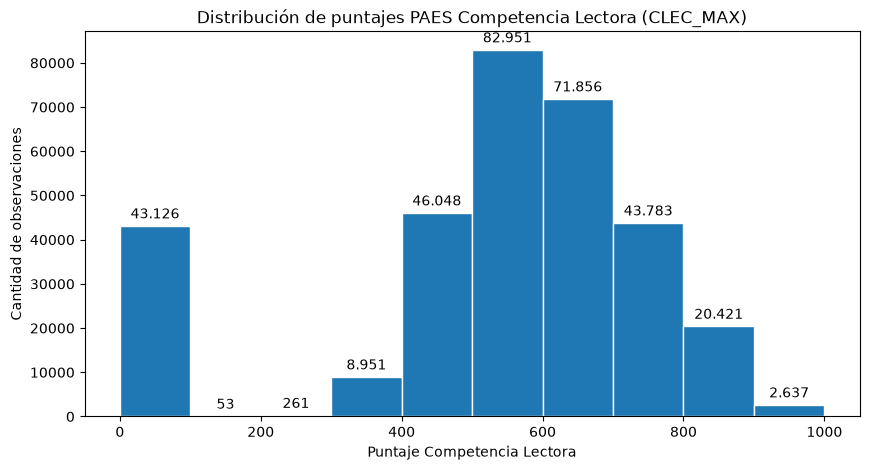

In [33]:
# Mismo grafico que value_counts pero en formato histograma, para visualizar la forma de la distribucion
plt.figure(figsize=(10, 5))

# bins=range(0, 1100, 100) define los cortes: 0, 100, 200, ..., 1000 (10 barras de 100 puntos cada una)
conteos, bordes, barras = plt.hist(
    inscritos["CLEC_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)

plt.xlabel("Puntaje Competencia Lectora")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Competencia Lectora (CLEC_MAX)")

# bar_label agrega el numero exacto de observaciones encima de cada barra (mas facil de leer que solo el eje Y)
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],  # formatea con punto de mil (estilo chileno)
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `CLEC_MAX` **no presenta valores nulos** (0,00%).
- **13,47% de las observaciones (43.126 casos)** registra un valor de cero.
- `CLEC_MAX` rescata un **5,72%** de casos que `CLEC_REG_ACTUAL` pierde por nulos, lo que respalda usarla como variable más "definitiva" para el análisis final.
- El 86,53% restante se distribuye de forma razonablemente simétrica entre 400 y 800 puntos.

Es necesario validar el criterio de tratamiento para los valores en cero (excluir o modelar como categoría "no rindió" separada del puntaje) antes de usar `CLEC_MAX` en el análisis final.

---
# Parte 2.1: Exploración de MATE1_MAX

Se replica exactamente el mismo procedimiento aplicado a `CLEC_MAX`, ahora sobre `MATE1_MAX` (puntaje máximo obtenido entre todas las rendiciones de la Prueba de Matemática 1).

Se mantiene el mismo criterio metodológico: describir primero, decidir después. 

## Foco de esta entrega: Contrastar comportamiento de `MATE1_MAX` en tanto a `CLEC_MAX` para el caso de estudio.

Según la ficha de metadatos, `MATE1_MAX` corresponde al puntaje máximo obtenido entre todas las Pruebas de Matemática 1 rendidas, a diferencia de `MATE1_REG_ACTUAL`, que refleja únicamente el resultado del proceso regular 2026.

In [34]:
# Verificamos el tipo de dato antes de cualquier calculo, misma comprobacion que se hizo para CLEC_MAX
MATE1_MAX_col = inscritos["MATE1_MAX"]
MATE1_MAX_col.dtype

dtype('int64')

Al igual que `CLEC_MAX`, `MATE1_MAX` ya viene como `int64`. Esto vuelve a ser indicio de ausencia de nulos (una columna `int64` con NaN habria sido forzada a `float64`), lo cual se confirma explicitamente a continuacion.

## Nulos vs. ceros

In [35]:
# Igual que en CLEC_MAX: se distingue explicitamente entre "no hay dato" (NaN) y "el dato es cero"
n_total = len(inscritos)
n_nulos = MATE1_MAX_col.isna().sum()
n_ceros = (MATE1_MAX_col == 0).sum()
n_validos = (MATE1_MAX_col > 0).sum()

resumen_mate1_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_mate1_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,46817,14.63
Puntaje > 0,273270,85.37


`MATE1_MAX` **no tiene valores nulos** (0,00%). Un **14,63% (46.817 casos)** registra un valor de cero. Al igual que en `CLEC_MAX`, esta prueba es de caracter obligatorio en el proceso de admision.

### Contraste con `MATE1_REG_ACTUAL`

Para dimensionar cuanto "rescata" `MATE1_MAX` frente a la variable de registro actual, se compara contra `MATE1_REG_ACTUAL`

In [36]:
# Conversion de MATE1_REG_ACTUAL a numerico.
reg_num = pd.to_numeric(inscritos["MATE1_REG_ACTUAL"], errors="coerce")

# Casos "rescatados": el estudiante no tiene dato en el proceso regular actual (NaN),
# pero SI tiene un puntaje maximo mayor a 0 en otra rendicion
rescatados = ((reg_num.isna()) & (MATE1_MAX_col > 0)).sum()

print("Nulos en MATE1_REG_ACTUAL:", reg_num.isna().sum(), f"({reg_num.isna().sum()/n_total*100:.2f}%)")
print("Ceros en MATE1_REG_ACTUAL:", (reg_num == 0).sum(), f"({(reg_num==0).sum()/n_total*100:.2f}%)")
print("Rescatados por MATE1_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en MATE1_REG_ACTUAL: 19496 (6.09%)
Ceros en MATE1_REG_ACTUAL: 54577 (17.05%)
Rescatados por MATE1_MAX:  18209 (5.69%)


`MATE1_MAX` rescata un 5,69% de estudiantes que `MATE1_REG_ACTUAL` pierde por nulos — una proporcion casi identica al 5,72% observado para `CLEC_MAX` en el notebook anterior. Esto refuerza la hipotesis del equipo: `MATE1_MAX` es una variable mas "definitiva" que su version de registro actual.

## Estadisticos descriptivos

In [37]:
# Tendencia central y dispersion, mismo bloque que en CLEC_MAX
print("Media:   ", MATE1_MAX_col.mean().round(1))
print("Mediana: ", MATE1_MAX_col.median().round(1))
print("Moda:    ", MATE1_MAX_col.mode().iloc[0], f"(n={n_ceros})")
print("Desv.Est:", MATE1_MAX_col.std().round(1))

Media:    544.9
Mediana:  587.0
Moda:     0 (n=46817)
Desv.Est: 264.5


Se aplica la misma logica de CLEC_MAX

## Distribucion por bandas de puntaje

In [38]:
# Mismas bandas de 100 en 100 puntos usadas para CLEC_MAX, para mantener comparabilidad entre variables
tabla_bandas = inscritos["MATE1_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

,Banda de puntaje,Observaciones,Porcentaje
0,"(-0.001, 100.0]",46836,14.63
1,"(100.0, 200.0]",12,0.00
2,"(200.0, 300.0]",81,0.03
3,"(300.0, 400.0]",3828,1.20
4,"(400.0, 500.0]",41712,13.03
5,"(500.0, 600.0]",82105,25.65
6,"(600.0, 700.0]",66888,20.90
7,"(700.0, 800.0]",34396,10.75
8,"(800.0, 900.0]",25264,7.89
9,"(900.0, 1000.0]",18965,5.92


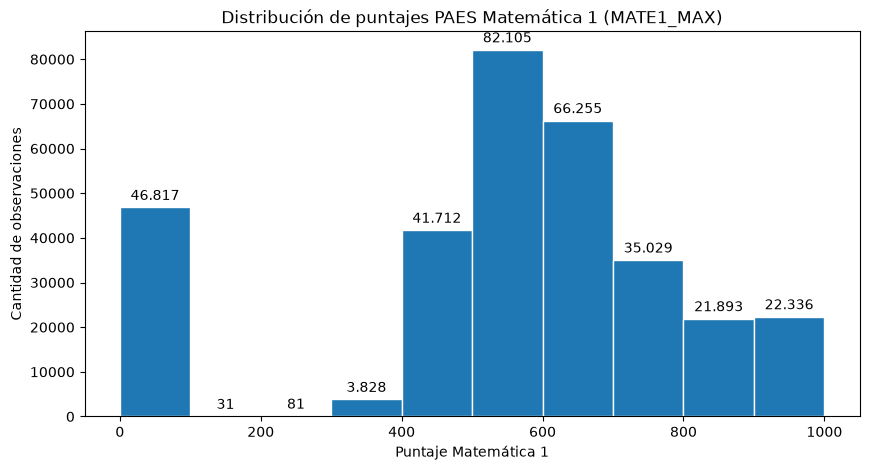

In [39]:
# Histograma con bandas de 100 puntos, mismo formato usado en CLEC_MAX y en 01_exploracion_datos.ipynb
plt.figure(figsize=(10, 5))
conteos, bordes, barras = plt.hist(
    inscritos["MATE1_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)
plt.xlabel("Puntaje Matemática 1")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Matemática 1 (MATE1_MAX)")
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `MATE1_MAX` **no presenta valores nulos** (0,00%).
- **14,63% de las observaciones (46.817 casos)** registra un valor de cero.
- `MATE1_MAX` rescata un **5,69%** de casos que `MATE1_REG_ACTUAL` pierde por nulos — cifra casi identica al 5,72% de `CLEC_MAX`, lo que refuerza que ambas variables `_MAX` son mas robustas que sus pares de registro actual.
- El 85,37% restante se distribuye entre 400 y 1000 puntos.

Misma condicion que CLEC_MAX, definir el tratamiento de los valores en cero antes del analisis final.

---
# Parte 2.2: Exploración de MATE2_MAX

Se aplica el mismo procedimiento descriptivo a `MATE2_MAX`.

A diferencia de `CLEC_MAX` y `MATE1_MAX` (pruebas obligatorias), la Prueba de Matemática 2 es de **caracter optativo** dentro del proceso de admision — solo la exigen ciertas carreras. Esto cambia la interpretacion de los resultados: aqui la proporcion de ceros no es un dato curioso al margen, sino el hallazgo central.

## Foco de esta entrega: `MATE2_MAX`

Según la ficha de metadatos, `MATE2_MAX` corresponde al puntaje máximo obtenido entre todas las Pruebas de Matemática 2 rendidas.

In [40]:
# Verificamos el tipo de dato, mismo primer paso que en las variables anteriores
MATE2_MAX_col = inscritos["MATE2_MAX"]
MATE2_MAX_col.dtype

dtype('int64')

Al igual que `CLEC_MAX` y `MATE1_MAX`, viene como `int64` — sin nulos por diseño de tipo. Se confirma a continuacion.

## Nulos vs. ceros

In [41]:
# Mismo criterio de las dos entregas anteriores: se distingue "no hay dato" (NaN) de "el dato es cero"
n_total = len(inscritos)
n_nulos = MATE2_MAX_col.isna().sum()
n_ceros = (MATE2_MAX_col == 0).sum()
n_validos = (MATE2_MAX_col > 0).sum()

resumen_mate2_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_mate2_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,193784,60.54
Puntaje > 0,126303,39.46


`MATE2_MAX` **no tiene valores nulos** (0,00%), pero **60,54% de las observaciones (193.784 casos)** registra un valor de cero — mas de la mitad del total. Esta proporcion es drasticamente mayor a la de `CLEC_MAX` (13,47%) y `MATE1_MAX` (14,63%).

### Contraste con `MATE2_REG_ACTUAL`: ¿es lo mismo que en CLEC_MAX y MATE1_MAX?

Se repite el cruce contra la variable de registro actual, igual que en `03_exploracion_mate1_max.ipynb`, para comparar si `MATE2_MAX` "rescata" una proporcion similar de casos.

In [42]:
# Conversion de MATE2_REG_ACTUAL a numerico (str -> numerico, mismo criterio que en notebooks anteriores)
reg_num = pd.to_numeric(inscritos["MATE2_REG_ACTUAL"], errors="coerce")

nulos_reg = reg_num.isna().sum()
ceros_reg = (reg_num == 0).sum()

# Casos "rescatados": sin dato en el proceso regular actual, pero con puntaje > 0 en MATE2_MAX
rescatados = ((reg_num.isna()) & (MATE2_MAX_col > 0)).sum()

print("Nulos en MATE2_REG_ACTUAL:", nulos_reg, f"({nulos_reg/n_total*100:.2f}%)")
print("Ceros en MATE2_REG_ACTUAL:", ceros_reg, f"({ceros_reg/n_total*100:.2f}%)")
print("Ceros en MATE2_MAX:       ", n_ceros, f"({n_ceros/n_total*100:.2f}%)")
print("Rescatados por MATE2_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en MATE2_REG_ACTUAL: 19496 (6.09%)
Ceros en MATE2_REG_ACTUAL: 193306 (60.39%)
Ceros en MATE2_MAX:        193784 (60.54%)
Rescatados por MATE2_MAX:  8533 (2.67%)


**Esto es lo que confirma la hipotesis del caracter optativo.** A diferencia de `CLEC_MAX` (rescata 5,72%) y `MATE1_MAX` (rescata 5,69%), `MATE2_MAX` solo rescata un **2,67%** de casos adicionales, y la tasa de ceros en `MATE2_REG_ACTUAL` (60,39%) es practicamente identica a la de `MATE2_MAX` (60,54%).

En otras palabras: los estudiantes que no registran `MATE2` en el proceso actual, mayoritariamente **tampoco la han rendido ** en procesos anteriores. Esto es consistente con una prueba optativa que gran parte de los postulantes simplemente no necesita rendir (no aplica a la carrera a la que postulan), y no con una prueba obligatoria con problemas puntuales de registro.

**Implicancia para el analisis final:** Se propone modelar `MATE2_MAX` en dos partes: (1) una variable binaria "rindio Matematica 2" y (2) evaluar estadisticas de puntaje condicional solo entre quienes si la rindieron

## Estadisticos descriptivos

In [43]:
# Igual que en las variables anteriores. Aqui la mediana = 0 es esperable dado que mas del 60% de los casos son cero
print("Media:   ", MATE2_MAX_col.mean().round(1))
print("Mediana: ", MATE2_MAX_col.median().round(1))
print("Moda:    ", MATE2_MAX_col.mode().iloc[0], f"(n={n_ceros})")
print("Desv.Est:", MATE2_MAX_col.std().round(1))

Media:    168.4
Mediana:  0.0
Moda:     0 (n=193784)
Desv.Est: 216.3


Se aplica el mismo criterio de las revisiones anteriores, considerando la magnitud de 0 que llega al 61% aproximado. 

## Distribucion por bandas de puntaje

In [44]:
# Mismas bandas de 100 en 100 puntos usadas en CLEC_MAX y MATE1_MAX, para mantener comparabilidad
tabla_bandas = inscritos["MATE2_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

,Banda de puntaje,Observaciones,Porcentaje
0,"(-0.001, 100.0]",193835,60.56
1,"(100.0, 200.0]",54,0.02
2,"(200.0, 300.0]",3347,1.05
3,"(300.0, 400.0]",55105,17.22
4,"(400.0, 500.0]",48876,15.27
5,"(500.0, 600.0]",11836,3.70
6,"(600.0, 700.0]",4842,1.51
7,"(700.0, 800.0]",1673,0.52
8,"(800.0, 900.0]",466,0.15
9,"(900.0, 1000.0]",53,0.02


Notese la forma inusual de la distribucion: despues del bloque masivo en 0-100, la segunda banda mas grande es 300-400 (17,22%), no 400-500 como en las otras dos variables. Entre quienes SI rinden Matematica 2, el patron de puntajes parece distinto al de Competencia Lectora y Matematica 1 — otra pista de que se trata de una subpoblacion distinta (probablemente con perfil mas orientado a carreras cientificas), no solo una version "con mas ceros" de las mismas pruebas.

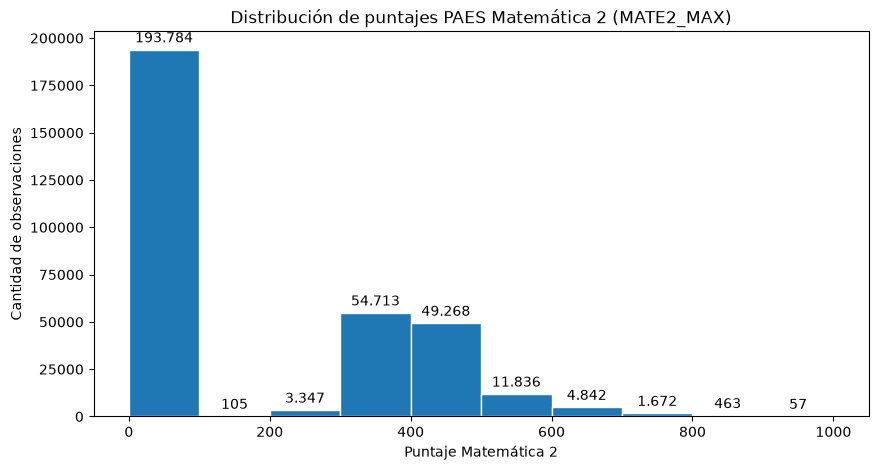

In [45]:
# Histograma con bandas de 100 puntos, mismo formato que CLEC_MAX y MATE1_MAX para comparabilidad visual
plt.figure(figsize=(10, 5))
conteos, bordes, barras = plt.hist(
    inscritos["MATE2_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)
plt.xlabel("Puntaje Matemática 2")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Matemática 2 (MATE2_MAX)")
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `MATE2_MAX` **no presenta valores nulos** (0,00%).
- **60,54% de las observaciones (193.784 casos)** registra un valor de cero.
- El cruce contra `MATE2_REG_ACTUAL` muestra que `MATE2_MAX` solo rescata un 2,67% de casos adicionales (vs. ~5,7% en `CLEC_MAX` y `MATE1_MAX`), y que la tasa de ceros es casi identica entre ambas variables (60,39% vs. 60,54%). Esto respalda con evidencia cuantitativa que el cero refleja **no-rendicion de una prueba optativa**.
- Entre quienes si rindieron (39,46% de los casos), la distribucion tiene una forma distinta a la de `CLEC_MAX`/`MATE1_MAX`, concentrada mas hacia 300-500 puntos.

A diferencia de `CLEC_MAX` y `MATE1_MAX`, para `MATE2_MAX` no basta con decidir si excluir o no los ceros — se sugiere evaluar tratarla como dos variables: (1) `RINDIO_MATE2` (binaria) y (2) el puntaje condicional a haberla rendido. Esta decision, junto con la de `CLEC_MAX` y `MATE1_MAX`, queda pendiente para la etapa de definicion de variables finales del proyecto.

---
# Parte 3: Checklist formal de calidad

Esta parte carga las cinco tablas de forma independiente (incluida `Inscritos` nuevamente): a diferencia de las Partes 2 a 2.2, aquí se necesitan además `Socioeconómico`, `Postulantes`, `Matrícula` y `Oferta`, que no estaban disponibles todavía. Se mantiene el diagnóstico `OK`/`ERROR` por carpeta tal como se validó originalmente, sin modificaciones.

## 1. Los datos y su calidad

### 1.1 Carga desde la fuente declarada

Las cinco tablas provienen del portal de datos abiertos del Ministerio de Educación (declarado en la formulación), sección Educación Superior: `datosabiertos.mineduc.cl/pruebas-de-admision-a-la-educacion-superior/`. Se cargan desde `data/raw`, cada una en la carpeta que le corresponde.

In [46]:
from pathlib import Path
import pandas as pd
import numpy as np

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw" / "2026"

# Carpetas esperadas dentro de data/raw, una por fuente (igual que en
# 00_verificacion_entorno.ipynb). Antes de leer nada, confirmamos que el
# archivo existe -- si no, un FileNotFoundError generico no dice cual falta.
carpetas = {
    "Inscritos":       "PAES-2026-Inscritos-Puntajes",
    "Socioeconomico":  "PAES-2026-Socioeconomicos",
    "Postulantes":      "PAES-2026-Postulantes",
    "Matricula":        "PAES-2026-Matricula",
    "Oferta":           "PAES-2026-Oferta-Definitiva-Programas",
}

for nombre, carpeta in carpetas.items():
    ruta = RAW_DIR / carpeta
    encontrados = list(ruta.glob("*.csv")) if ruta.exists() else []
    if encontrados:
        print(f"OK    - {nombre:15s} -> {encontrados[0].name}")
    else:
        print(f"ERROR - {nombre:15s} -> no se encontro ningun .csv en {ruta}")

OK    - Inscritos       -> A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv
OK    - Socioeconomico  -> B_SOCIOECONOMICO_DOMICILIO_PAES_2026_PUB_MRUN.csv
OK    - Postulantes     -> C_POSTULANTES_SELECCION_PAES_2026_PUB_MRUN.csv
OK    - Matricula       -> D_MATRICULA_PAES_2026_2026_PUB_MRUN.csv
OK    - Oferta          -> OFERTA_DEFINITIVA_PROGRAMAS_PAES_2026.csv


Si alguna fila muestra `ERROR`, no seguir a la celda siguiente — revisar el nombre de la carpeta o si el `.csv` fue descomprimido en el lugar correcto. Confirmado que las 5 carpetas están OK, se cargan:

In [47]:
# Igual que arriba, pero usando glob() para tomar el .csv que encuentre en
# cada carpeta -- evita depender de escribir el nombre exacto del archivo.
bases = {}
for nombre, carpeta in carpetas.items():
    archivo = list((RAW_DIR / carpeta).glob("*.csv"))[0]
    if nombre == "Oferta":
        # Unica base con formato distinto: separador coma y comillas dobles
        bases[nombre] = pd.read_csv(archivo, sep=",", decimal=".")
    else:
        # sep=";" y decimal="," : formato confirmado en 01_exploracion_datos.ipynb
        bases[nombre] = pd.read_csv(archivo, sep=";", decimal=",", low_memory=False)

# Referencias cortas para el resto del notebook
A, B, C, D, O = bases["Inscritos"], bases["Socioeconomico"], bases["Postulantes"], bases["Matricula"], bases["Oferta"]

Con las cinco tablas cargadas, revisamos dimensiones y tipos en una sola pasada:

In [48]:
# Un ciclo for para no repetir el mismo bloque 5 veces: shape + info por tabla
for nombre, df in bases.items():
    print(f"{'=' * 10}")
    print(f"DATAFRAME: {nombre}")
    print(f"Dimensiones: {df.shape}")
    print()

DATAFRAME: Inscritos
Dimensiones: (320087, 131)

DATAFRAME: Socioeconomico
Dimensiones: (320087, 10)

DATAFRAME: Postulantes
Dimensiones: (1694081, 9)

DATAFRAME: Matricula
Dimensiones: (146873, 10)

DATAFRAME: Oferta
Dimensiones: (2150, 23)



Coincide exactamente con lo declarado en la formulación del proyecto (320.087 / 320.087 / 1.694.081 / 146.873 / 2.150). El tamaño combinado de las cinco tablas es consistente con los ~320 MB por proceso reportados en la estrategia de obtención.

### 1.2 Tipos de las variables relevantes

El proyecto no usa las 131+10+9+10+23 columnas disponibles, sino un subconjunto declarado en la formulación. Revisamos el tipo de cada una.

In [49]:
# Diccionario: base -> lista de variables que realmente usa el proyecto,
# segun la tabla "Variables relevantes" de la formulacion.
variables_por_base = {
    "Inscritos": ["MRUN","PTJE_NEM","PTJE_RANKING","CLEC_MAX","MATE1_MAX","MATE2_MAX",
                  "HCSOC_MAX","CIEN_MAX","HABILITACION_POST","DEPENDENCIA","RAMA_EDUCACIONAL"],
    "Socioeconomico": ["MRUN","INGRESO_PERCAPITA_GRUPO_FA"],
    "Postulantes": ["MRUN","ORDEN_PREF","ESTADO_PREF","PTJE_PREF","TIPO_PREF"],
    "Oferta": ["NEM","RANKING","CLEC","M1","HSCO","CIEN","M2","VAC_1ER"],
}

# Otro ciclo for: mismo chequeo (.dtypes) repetido para cada base, sin copiar y pegar
for nombre, cols in variables_por_base.items():
    print(f"--- {nombre} ---")
    print(bases[nombre][cols].dtypes)
    print()

--- Inscritos ---
MRUN                 int64
PTJE_NEM             int64
PTJE_RANKING         int64
CLEC_MAX             int64
MATE1_MAX            int64
MATE2_MAX            int64
HCSOC_MAX            int64
CIEN_MAX             int64
HABILITACION_POST    int64
DEPENDENCIA            str
RAMA_EDUCACIONAL       str
dtype: object

--- Socioeconomico ---
MRUN                          int64
INGRESO_PERCAPITA_GRUPO_FA    int64
dtype: object

--- Postulantes ---
MRUN           int64
ORDEN_PREF     int64
ESTADO_PREF    int64
PTJE_PREF        str
TIPO_PREF        str
dtype: object

--- Oferta ---
NEM          int64
RANKING      int64
CLEC         int64
M1           int64
HSCO       float64
CIEN       float64
M2         float64
VAC_1ER      int64
dtype: object



Dos hallazgos:

- **`PTJE_PREF`, de la tabla Postulantes llega como texto** (`str`), igual que le pasó a `CLEC_REG_ACTUAL`. Se revisa en la sección de valores disfrazados.
- **Para la tabla Oferta: `HSCO`, `CIEN` y `M2`, aparecen como `float64`**, dado el trabajo previo, es la primera pista de que tienen `NaN`: no todas las carreras ponderan estas tres pruebas, y pandas usa `float64` en vez de `int64` justamente porque hay ausencias reales en la columna.

### 1.3 Duplicados: fila completa y por llave

Se revisan en dos niveles, como corresponde: fila completa primero, y luego la llave que identifica a cada observación.

In [50]:
# Nivel 1: filas completas repetidas en cada tabla
for nombre, df in bases.items():
    print(f"{nombre:15s} {df.duplicated().sum()} filas duplicadas")

Inscritos       0 filas duplicadas
Socioeconomico  0 filas duplicadas
Postulantes     0 filas duplicadas
Matricula       0 filas duplicadas
Oferta          0 filas duplicadas


In [51]:
# Nivel 2: la llave que identifica a cada estudiante/observacion.
# En Inscritos, Socioeconomico y Matricula, MRUN deberia ser unico (una fila por estudiante).
print("MRUN duplicado en Inscritos:      ", A["MRUN"].duplicated().sum())
print("MRUN duplicado en Socioeconomico: ", B["MRUN"].duplicated().sum())
print("MRUN duplicado en Matricula:      ", D["MRUN"].duplicated().sum())

# En Postulantes, MRUN se repite por diseno (una fila por preferencia), asi que
# probamos primero con (MRUN, ORDEN_PREF), que deberia ser la llave logica.
print("\n(MRUN, ORDEN_PREF) duplicado en Postulantes:", C.duplicated(subset=["MRUN","ORDEN_PREF"]).sum())

MRUN duplicado en Inscritos:       0
MRUN duplicado en Socioeconomico:  0
MRUN duplicado en Matricula:       0

(MRUN, ORDEN_PREF) duplicado en Postulantes: 280569


`(MRUN, ORDEN_PREF)` da 280.569 duplicados — un número demasiado grande para ser error de carga. Antes de reportarlo como problema, se investiga un caso concreto:

In [52]:
# Aislamos un MRUN con la combinacion repetida para ver que esta pasando
dup_mask = C.duplicated(subset=["MRUN","ORDEN_PREF"], keep=False)
ejemplo = C.loc[dup_mask, "MRUN"].iloc[0]
print(C.loc[C["MRUN"] == ejemplo, ["MRUN","ORDEN_PREF","TIPO_PREF","COD_CARRERA_PREF"]].sort_values("ORDEN_PREF").to_string(index=False))

 MRUN  ORDEN_PREF TIPO_PREF  COD_CARRERA_PREF
   89           1   REGULAR             47001
   89           2   REGULAR             47002
   89           3   REGULAR             12025
   89           4   REGULAR             41037
   89           5   REGULAR             41082
   89           6   REGULAR             47491
   89           7   REGULAR             41068
   89           8   REGULAR             41072
   89           9   REGULAR             41136
   89          10   REGULAR             11522
   89          11   REGULAR             41002
   89          12   REGULAR             12006
   89          13   REGULAR             41031
   89          14    GENERO             16109
   89          14   REGULAR             16109
   89          15   REGULAR             41023


La preferencia N°14 aparece dos veces para el mismo `MRUN`: una vez como `REGULAR` y otra como `GENERO`, ambas apuntando a la misma carrera (`16109`). No es un duplicado real — un estudiante puede postular a la misma carrera por la vía regular y, en paralelo, por la vía de cupos de género, cada una con su propio proceso de selección. La llave que sí identifica una fila de forma única incluye la vía:

In [53]:
# Repetimos duplicated() agregando TIPO_PREF a la llave, para confirmar
# que ahora si es 0: cada (estudiante, posicion, via) debe ser unico.
print("(MRUN, ORDEN_PREF, TIPO_PREF) duplicado en Postulantes:", C.duplicated(subset=["MRUN","ORDEN_PREF","TIPO_PREF"]).sum())

(MRUN, ORDEN_PREF, TIPO_PREF) duplicado en Postulantes: 0


**Decisión documentada:** la llave única de `Postulantes` es `(MRUN, ORDEN_PREF, TIPO_PREF)`, no `(MRUN, ORDEN_PREF)`. Se usará esta llave en cualquier merge o verificación posterior sobre esta tabla.

### 1.4 Valores faltantes: reales y disfrazados

Un `NaN` es fácil de contar con `.isna()`. El problema son los valores que existen pero no son información real — hay que revisarlos variable por variable, porque un chequeo genérico no los detecta.

In [54]:
# Puntajes de Inscritos: en un dato int64 sin NaN, un valor de 0 sobre una escala
# de 100-1000 no puede ser un puntaje real -> es sospechoso de ser un flatante disfrazado.
cols_puntaje = ["PTJE_NEM","PTJE_RANKING","CLEC_MAX","MATE1_MAX","MATE2_MAX","HCSOC_MAX","CIEN_MAX"]
for col in cols_puntaje:
    nulos = A[col].isna().sum()
    ceros = (A[col] == 0).sum()
    print(f"{col:15s} nulos reales: {nulos:>2}   en cero: {ceros:>7} ({ceros/len(A)*100:5.2f}%)")

PTJE_NEM        nulos reales:  0   en cero:    6129 ( 1.91%)
PTJE_RANKING    nulos reales:  0   en cero:    6129 ( 1.91%)
CLEC_MAX        nulos reales:  0   en cero:   43126 (13.47%)
MATE1_MAX       nulos reales:  0   en cero:   46817 (14.63%)
MATE2_MAX       nulos reales:  0   en cero:  193784 (60.54%)
HCSOC_MAX       nulos reales:  0   en cero:  172002 (53.74%)
CIEN_MAX        nulos reales:  0   en cero:  123646 (38.63%)


**Decisión documentada:** ninguna de las siete tiene `NaN`, pero todas tienen ceros que indican un "no rindió" en vez de "puntaje 0" — más marcado en `MATE2_MAX`, `HCSOC_MAX` y `CIEN_MAX`, que son pruebas optativas (confirmado más abajo con el código `ESTADO_PREF = 35`, "no rindió ninguna de las pruebas opcionales"). El tratamiento de estos ceros queda pendiente para la etapa de modelado; aquí solo se documenta la magnitud.

In [55]:
# INGRESO_PERCAPITA_GRUPO_FA: el diccionario oficial define 1-10 como deciles
# y 99 como "Prefiere no responder" -- un valor valido para pandas, pero
# que para el analisis socioeconomico funciona como un dato faltante.
print(B["INGRESO_PERCAPITA_GRUPO_FA"].value_counts().sort_index())
n_99 = (B["INGRESO_PERCAPITA_GRUPO_FA"] == 99).sum()
print(f"\nCodigo 99 ('prefiere no responder'): {n_99} casos ({n_99/len(B)*100:.2f}%)")

INGRESO_PERCAPITA_GRUPO_FA
1     44641
2     33590
3     23658
4     21701
5     17318
6     15915
7     25266
8     20715
9     14455
10    14448
99    88380
Name: count, dtype: int64

Codigo 99 ('prefiere no responder'): 88380 casos (27.61%)


**Decisión documentada:** `INGRESO_PERCAPITA_GRUPO_FA = 99` se trata como faltante disfrazado, no como un decil real. Con 27,61% de los casos en esta categoría, cualquier análisis por decil socioeconómico (relevante para la hipótesis del proyecto) debe reportar este porcentaje como base excluida, no ignorarlo.

In [56]:
# PTJE_PREF llego como texto. Antes de asumir el motivo,
# probamos la conversion directa y aislamos lo que falla.
convertido = pd.to_numeric(C["PTJE_PREF"], errors="coerce")
fallidos = convertido.isna()
print("Filas que no convierten a numero:", fallidos.sum(), f"({fallidos.sum()/len(C)*100:.2f}%)")

# Aplicamos .unique() sobre los valores originales que fallaron, para ver que caracter es.
# Guardamos el resultado en vez de imprimirlo directo ya que son demasiados valores
# y pandas los muestra truncados, lo que esconde justamente lo que hay que ver.
valores_que_fallan = C.loc[fallidos, "PTJE_PREF"].unique()
print("Cantidad de valores distintos que fallan:", len(valores_que_fallan))
print("Muestra:", valores_que_fallan[:5])

Filas que no convierten a numero: 1694081 (100.00%)
Cantidad de valores distintos que fallan: 40626
Muestra: <StringArray>
['666,100', '667,100', '665,800', '621,200', '656,400']
Length: 5, dtype: str


Falla el 100% de las filas, y los 40.626 valores distintos que fallan son puntajes bien formados del tipo '666,100'. 

Por lo tanto, la razon de esta falla es la lectura, cuando le pasamos decimal="," a read_csv es necesario que la columna sea numérica de lo contrario no actua.

In [57]:
# Como falla el 100%, lo que hay que revisar es la columna completa.
# La idea es ver si todo lo que no convierte es de la misma naturaleza
# o si hay mas de un fenomeno mezclado.
print("Total de filas :", len(C))
print("  en blanco    :", (C["PTJE_PREF"].str.strip() == "").sum())
print("  con coma     :", C["PTJE_PREF"].str.contains(",").sum())

Total de filas : 1694081
  en blanco    : 131859
  con coma     : 1562222


Como PTJE_REF trae celdas en blanco (131859), Pandas la dejo como texto.

Ahora que sabemos las categorias del error, Blancos y con Comas, hacemos la corrección.

In [58]:
# Causa 1 (formato): normalizamos la coma a punto, que es lo que to_numeric espera.
PTJE_PREF_TEXTO = C["PTJE_PREF"].str.replace(",", ".", regex=False)

# Causa 2 (dato faltante): recien ahora, lo que siga sin convertir es un faltante real.
convertido = pd.to_numeric(PTJE_PREF_TEXTO, errors="coerce")
fallidos = convertido.isna()

print("Filas sin puntaje ponderado:", fallidos.sum(), f"({fallidos.sum()/len(C)*100:.2f}%)")
print("Valor(es) que quedan sin convertir:", C.loc[fallidos, "PTJE_PREF"].unique())

Filas sin puntaje ponderado: 131859 (7.78%)
Valor(es) que quedan sin convertir: <StringArray>
[' ']
Length: 1, dtype: str


In [59]:
# Guardamos la version numerica para el resto del proyecto, con el mismo
# criterio de nombre que usamos en CLEC_REG_ACTUAL_2_NUM.
PTJE_PREF_NUM = convertido

PTJE_PREF_NUM.describe().round(2)

count    1562222.00
mean         705.87
std          120.59
min          300.50
25%          616.80
50%          695.70
75%          784.70
max         1130.00
Name: PTJE_PREF, dtype: float64

El `describe()` deja dos cosas a la vista: el mínimo es 300,50 y el máximo 1130,00. Ese máximo está fuera de la escala 100-1000 que declaramos para `PTJE_PREF` en la formulación del proyecto; el diccionario oficial no declara rango para esta variable. Corregimos el dominio declarado: `PTJE_PREF` es un puntaje ponderado y puede superar los 1000. El origen de esos valores se revisa en la Sección 2, al abrir el puntaje por vía de admisión.

In [60]:
# Cruzamos los PTJE_PREF en blanco con su ESTADO_PREF: si el patron es real,
# deberian concentrarse en causales de anulacion y no en preferencias que compitieron.
print("--- ESTADO_PREF de las preferencias SIN puntaje ---")
print(C.loc[fallidos, "ESTADO_PREF"].value_counts().sort_index())

# El complemento cierra el argumento: si las preferencias CON puntaje son solo
# 24, 25 y 26, entonces la relacion se cumple en las dos direcciones.
print("\n--- ESTADO_PREF de las preferencias CON puntaje ---")
print(C.loc[~fallidos, "ESTADO_PREF"].value_counts().sort_index())

--- ESTADO_PREF de las preferencias SIN puntaje ---
ESTADO_PREF
9      4188
15       16
17     7694
19      296
20      582
22       35
23       47
27     1433
28     1495
29     2674
30     5204
31     9394
35     7432
36    25156
40    15288
42    11084
51    39518
52      323
Name: count, dtype: int64

--- ESTADO_PREF de las preferencias CON puntaje ---
ESTADO_PREF
24     161907
25     387815
26    1012500
Name: count, dtype: int64


**Decisión documentada:** ninguno de los códigos sin puntaje corresponde a `24` (seleccionado), `25` (espera) o `26` (seleccionado antes), todos son causales de anulación (falta de NEM, no cumple el ponderado mínimo de la carrera, pre-habilitación PACE, etc., según el Anexo I del diccionario oficial). Y al revés también: las preferencias con puntaje son solo esos tres estados, sin un caso cruzado. El blanco en `PTJE_PREF` no es un error: la base solo publica el ponderado de las preferencias que llegaron a competir por un cupo. Se tratará como `NaN` real en los análisis siguientes, con esta causa documentada.

### 1.5 Valores imposibles según el dominio

In [61]:
# DEPENDENCIA: el diccionario declara codigos 1 a 6. Revisamos si existe algo mas.
print(A["DEPENDENCIA"].value_counts(dropna=False).sort_index())

DEPENDENCIA
       3200
1     19922
2     48543
3    168231
4     35248
5     10571
6     34372
Name: count, dtype: int64


**Decisión documentada:** 3.200 filas (1,00%) tienen `DEPENDENCIA` en blanco, fuera del dominio declarado (1-6). Es la misma cantidad que falta en `NOMBRE_UNIDAD_EDUC` y `NOMBRE_COMUNA_EGRESO` según el `.info()` de la Parte 1: se trata de inscritos sin establecimiento de egreso registrado, y sin establecimiento no hay dependencia ni comuna que informar. Se excluyen de todo análisis por dependencia, que es la variable de la hipótesis, documentando la pérdida (1,00% de los inscritos).

In [62]:
# Ponderaciones de Oferta: cada programa deberia ponderar un total de 100%
# entre las 7 pruebas. Sumamos ingenuamente primero.
cols_pond = ["NEM","RANKING","CLEC","M1","HSCO","CIEN","M2"]
suma_ingenua = O[cols_pond].sum(axis=1)
print("Suma ingenua != 100:", (suma_ingenua != 100).sum(), "de", len(O), "programas")

Suma ingenua != 100: 1411 de 2150 programas


1.411 de 2.150 programas (65,6%) no suman 100 al sumar las 7 columnas directamente. Antes de reportar esto como un error masivo del dato, se revisó una ponderación real y vigente (Arquitectura, U. de Chile, admisión 2027): Historia y Ciencias no son dos pesos que se suman, son **un solo cupo de 10% que se llena con el mejor puntaje entre ambas pruebas** — el mismo criterio que "puntaje `_MAX`" aplica a nivel de ponderación.

In [63]:
# Corregimos: en vez de sumar HSCO + CIEN, usamos el maximo entre ambas
# (fillna(0) porque una carrera puede no pedir ninguna de las dos).
hsco_o_cien = O[["HSCO","CIEN"]].max(axis=1, skipna=True).fillna(0)
suma_corregida = O[["NEM","RANKING","CLEC","M1","M2"]].sum(axis=1) + hsco_o_cien

print("Suma corregida != 100:", (suma_corregida.round(2) != 100).sum(), "de", len(O), "programas")
print()
print("Carreras que persisten sin sumar 100:")
print(O.loc[suma_corregida.round(2) != 100, "CARRERA"].tolist())

Suma corregida != 100: 10 de 2150 programas

Carreras que persisten sin sumar 100:
['ACTUACIÓN TEATRAL', 'LICENCIADO/A EN ARTES CON MENCIÓN EN COMPOSICIÓN', 'DANZA', 'ACTUACIÓN', 'LICENCIATURA EN INTERPRETACIÓN MUSICAL', 'LICENCIATURA EN MÚSICA', 'ARTES MUSICALES Y SONORAS (VALDIVIA)', 'TEATRO', 'LICENCIATURA EN INTERPRETACIÓN Y FORMACIÓN MUSICAL ESPECIALIZADA', 'ACTUACIÓN Y CREACIÓN TEATRAL']


**Decisión documentada:** al usar el máximo entre `HSCO` y `CIEN` en vez de sumarlas, el problema baja de 1.411 a solo 10 programas (0,47%). Los 10 restantes son carreras artísticas (actuación, danza, música, teatro), que en la práctica exigen además una **prueba especial o audición** (confirmado contra un caso real: la ponderación oficial de Danza declara explícitamente una "Prueba Especial" que constituye el 50% del puntaje final) — un componente que esta base de Oferta no captura porque no forma parte del sistema PAES centralizado. No es un error del dato: es una limitación de cobertura, y se documenta como tal. Para el cálculo del puntaje ponderado del proyecto, se usará `MAX(HSCO, CIEN)` como ponderación conjunta, y se excluirán o marcarán aparte los 10 programas artísticos identificados.

### 1.6 Merges verificados: filas antes y después

In [64]:
# A + Socioeconomico: ambas tablas tienen 320.087 filas y comparten MRUN,
# deberian calzar 1 a 1 sin perdidas.
ab = A[["MRUN"]].merge(B[["MRUN","INGRESO_PERCAPITA_GRUPO_FA"]], on="MRUN", how="left")
print("Filas de A:", len(A), "| Filas tras merge A+B:", len(ab))
print("Filas de A sin match en B:", ab["INGRESO_PERCAPITA_GRUPO_FA"].isna().sum())

Filas de A: 320087 | Filas tras merge A+B: 320087
Filas de A sin match en B: 0


Sin pérdidas: A y B comparten exactamente la misma población de `MRUN`, como corresponde a dos vistas del mismo proceso de inscripción.

In [65]:
# A + Matricula: D es un subconjunto esperado de A (solo quienes matricularon).
ad = A[["MRUN"]].merge(D[["MRUN","NOMBRE_CARRERA"]], on="MRUN", how="left")
matricularon = ad["NOMBRE_CARRERA"].notna().sum()
print("Filas de A:", len(A), "| Filas tras merge A+D:", len(ad))
print("De A, matricularon:", matricularon, f"({matricularon/len(A)*100:.2f}%)")
print()

# Verificamos en el otro sentido: hay MRUN de D que no esten en A?
en_d_no_en_a = (~D["MRUN"].isin(A["MRUN"])).sum()
print("MRUN de D (matricula) que NO aparecen en A (inscritos):", en_d_no_en_a)
print("D total:", len(D), "= matricularon segun A (", matricularon, ") + no encontrados (", en_d_no_en_a, ")")

Filas de A: 320087 | Filas tras merge A+D: 320087
De A, matricularon: 141402 (44.18%)

MRUN de D (matricula) que NO aparecen en A (inscritos): 5471
D total: 146873 = matricularon segun A ( 141402 ) + no encontrados ( 5471 )


**Decisión documentada:** 5.471 matriculados (3,73% de `D`) no aparecen en la base de inscritos PAES en absoluto — no es un error de merge, sino evidencia de vías de ingreso que no requieren rendir la PAES del proceso vigente (por ejemplo, segunda carrera o admisión de titulados/graduados). Estos 5.471 casos quedan fuera del alcance del proyecto, que se centra en el embudo de postulación PAES 2026; se documenta la exclusión.

### 1.7 Síntesis de calidad por tabla

In [66]:
# Tabla-resumen final: una fila por base, con lo encontrado en 1.3-1.6.
# No reemplaza el detalle de arriba, lo deja visible de un vistazo.
resumen_calidad = pd.DataFrame({
    "Tabla": ["Inscritos", "Socioeconomico", "Postulantes", "Matricula", "Oferta"],
    "Filas": [len(A), len(B), len(C), len(D), len(O)],
    "Duplicados (fila)": [0, 0, 0, 0, 0],
    "Faltantes disfrazados": [
        "CLEC/MATE1/MATE2/HCSOC/CIEN_MAX = 0 (centinela, no NaN)",
        "INGRESO_PERCAPITA_GRUPO_FA = 99 (27.61%)",
        "PTJE_PREF = ' ' (7.78%)",
        "Sin hallazgos nuevos (ver Inscritos para NOMBRE_REGION_EGRESO)",
        "Ponderaciones no capturan pruebas especiales (10 programas)",
    ],
    "Valor fuera de dominio": [
        "DEPENDENCIA en blanco (1.00%)",
        "-",
        "-",
        "-",
        "-",
    ],
})
resumen_calidad

,Tabla,Filas,Duplicados (fila),Faltantes disfrazados,Valor fuera de dominio
0,Inscritos,320087,0,CLEC/MATE1/MATE2/HCSOC/CIEN_MAX = 0 (centinela...,DEPENDENCIA en blanco (1.00%)
1,Socioeconomico,320087,0,INGRESO_PERCAPITA_GRUPO_FA = 99 (27.61%),-
2,Postulantes,1694081,0,PTJE_PREF = ' ' (7.78%),-
3,Matricula,146873,0,Sin hallazgos nuevos (ver Inscritos para NOMBR...,-
4,Oferta,2150,0,Ponderaciones no capturan pruebas especiales (...,-


## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para la exploración de calidad de datos de este notebook: identificación y verificación de valores disfrazados, revisión de merges, y redacción de las interpretaciones. Se utilizó además **ChatGPT** para el código de visualización (histograma), reutilizado como base para los gráficos de notebooks previos del proyecto. El diseño de la pregunta de investigación, las decisiones metodológicas y la verificación final de cada hallazgo son del equipo; todas las cifras son reproducibles sobre las bases públicas declaradas.